# Hybrid CNN-LSTM Model for Dysgraphia Detection

## Overview

This notebook trains a **Hybrid CNN-LSTM model** for dysgraphia detection.

### Model Architecture:
- **CNN Block**: Extracts local spatial/temporal features (2 convolutional layers)
- **Bidirectional LSTM**: Processes CNN features as sequences for long-term patterns
- **Classification Head**: Final prediction layer

### Why CNN-LSTM Hybrid?
- **CNN**: Captures local patterns (stroke-level features)
- **LSTM**: Models long-term temporal dependencies (word-level patterns)
- **Best of Both**: Combines local feature extraction with sequential modeling
- **Bidirectional**: Captures both forward and backward temporal context

### Prerequisites:
1. Run `00_initialization.ipynb` first to set up data and functions
2. Ensure `meta_df` and all helper functions are available

## 0. Run Initialization First (Required)

**Run the cell below once** to load `meta_df`, `Config`, and all helper functions from `00_initialization.ipynb`.  
If you've already run `00_initialization.ipynb` in this kernel, you can skip this.

In [1]:
# Load meta_df, Config, and helpers. Run this cell once at the start.
import os
import sys
# Ensure project folder is in path (for dysxai_init import)
for _d in [os.getcwd(), os.path.dirname(os.path.abspath("03_model_cnnlstm.ipynb")), 
           r"C:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI"]:
    if _d and os.path.exists(os.path.join(_d, "dysxai_init.py")):
        if _d not in sys.path:
            sys.path.insert(0, _d)
        break

if 'meta_df' not in globals():
    try:
        import dysxai_init
        for name in ['Config', 'load_metadata', 'load_raw_timeseries', 'discover_files_and_map_subjects',
                     'compute_derivatives', 'pad_truncate', 'MixedFeatureScaler', 'fit_scaler_on_train', 'fit_scaler_from_train_meta',
                     'apply_scaler', 'HandwritingDataset', 'subject_independent_split']:
            globals()[name] = getattr(dysxai_init, name)
        meta_df = dysxai_init.run_init(verbose=True)
        globals()['meta_df'] = meta_df
        print("✓ Loaded meta_df and helpers from dysxai_init.py")
    except Exception as e:
        print(f"Error: {e}")
        print("Alternative: Run 00_initialization.ipynb (all cells) first, then run this notebook in the SAME kernel.")
        raise
else:
    print("✓ meta_df already available.")

Looking for files in: c:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI\dataSciRep_public
✓ Loaded 121 samples from 120 subjects
✓ Loaded meta_df and helpers from dysxai_init.py


## 1. Model Definition

Define the CNN-LSTM hybrid model.

In [2]:
# Import necessary modules (assumes 00_initialization.ipynb was run)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# CNN-LSTM Hybrid Model
class CNNLSTMModel(nn.Module):
    """
    Hybrid CNN-LSTM model for dysgraphia detection.
    
    Architecture:
    1. CNN block extracts local spatial/temporal features
    2. Bidirectional LSTM processes the CNN features as a sequence
    3. Classification head for final prediction
    """
    def __init__(self, in_channels: int, num_classes: int = 2,
                 lstm_hidden_size: int = 64, lstm_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        
        # 1. CNN Block for Feature Extraction (Local patterns)
        self.cnn_extractor = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # After 2 MaxPool operations, sequence length is divided by 4
        
        # 2. Bidirectional LSTM for Temporal Evolution
        self.lstm = nn.LSTM(
            input_size=128,  # Output channels from CNN
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )
        
        # 3. Classification head
        # *2 for bidirectional (forward + backward hidden states)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden_size * 2, num_classes)
    
    def forward(self, x, lengths=None):
        """
        Forward pass.
        
        Args:
            x: (B, C, T) input tensor
            lengths: (B,) true sequence lengths (optional)
        Returns:
            logits: (B, num_classes) classification logits
            features: (B, 128, T/4) CNN feature maps (for XAI)
        """
        # 1. Extract local features with CNN
        features = self.cnn_extractor(x)  # (B, 128, T/4)
        
        # 2. Prepare for LSTM (permute to B, T, C format)
        features_seq = features.permute(0, 2, 1)  # (B, T/4, 128)
        
        # 3. LSTM processing
        lstm_out, (h_n, c_n) = self.lstm(features_seq)
        
        # 4. Global Pooling: Concatenate final forward and backward hidden states
        hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)  # (B, hidden_size*2)
        
        # 5. Classification
        out = self.dropout(hidden)
        logits = self.classifier(out)
        
        return logits, features

print("✓ CNN-LSTM Model defined")

✓ CNN-LSTM Model defined


## 2. Training Functions

Same training functions as other model notebooks.

In [ ]:
# Metrics function
def compute_metrics(y_true, y_pred_probs):
    y_true = np.asarray(y_true)
    y_pred_probs = np.asarray(y_pred_probs)
    y_pred = (y_pred_probs >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    try:
        auc = roc_auc_score(y_true, y_pred_probs)
    except ValueError:
        auc = np.nan
    return {"accuracy": acc, "sensitivity": sensitivity, "specificity": specificity, "auc": auc, "confusion_matrix": cm}

# Training function
def train_one_model(train_loader, val_loader, test_loader, model, num_epochs, class_weights, lr, weight_decay, device, early_stopping_patience=5, early_stopping_enabled=True):
    """
    Train a model with early stopping on validation set and final evaluation on test set.
    
    Args:
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data (used for early stopping and hyperparameter tuning)
        test_loader: DataLoader for test data (used ONLY for final evaluation)
        model: PyTorch model to train
        num_epochs: Maximum number of training epochs
        class_weights: Class weights for loss function
        lr: Learning rate
        weight_decay: L2 regularization weight
        device: Device to train on
        early_stopping_patience: Patience for early stopping
        early_stopping_enabled: Whether to enable early stopping
        
    Returns:
        model: Trained model (restored to best validation performance)
        history: Dictionary with training history
        test_metrics: Final test set metrics (computed at the end)
    """
    model.to(device)
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    history = {"train_loss": [], "val_loss": [], "val_metrics": []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    best_epoch = 0
    
    # Training loop
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
            x, y, lengths = batch["x"].to(device), batch["y"].to(device), batch["length"].to(device)
            optimizer.zero_grad()
            logits, _ = model(x, lengths)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = float(np.mean(train_losses))
        
        # Validation evaluation (for early stopping and hyperparameter tuning)
        model.eval()
        val_losses, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
                x, y, lengths = batch["x"].to(device), batch["y"].to(device), batch["length"].to(device)
                logits, _ = model(x, lengths)
                val_losses.append(criterion(logits, y).item())
                probs = torch.softmax(logits, dim=1)[:, 1]
                all_probs.append(probs.cpu().numpy())
                all_labels.append(y.cpu().numpy())
        avg_val_loss = float(np.mean(val_losses))
        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        metrics = compute_metrics(all_labels, all_probs)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_metrics"].append(metrics)
        
        # Early stopping logic based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}, Val Acc: {metrics['accuracy']:.4f}, Val AUC: {metrics['auc']:.4f}")
        scheduler.step(avg_val_loss)
        
        if early_stopping_enabled and patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}. Best: epoch {best_epoch}")
            break
    
    # Restore best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored weights from epoch {best_epoch}")
    
    # Final evaluation on TEST set (unseen data)
    print("\n" + "=" * 60)
    print("FINAL TEST SET EVALUATION")
    print("=" * 60)
    model.eval()
    all_test_probs, all_test_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating on Test Set", leave=False):
            x, y, lengths = batch["x"].to(device), batch["y"].to(device), batch["length"].to(device)
            logits, _ = model(x, lengths)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_test_probs.append(probs.cpu().numpy())
            all_test_labels.append(y.cpu().numpy())
    
    all_test_probs = np.concatenate(all_test_probs)
    all_test_labels = np.concatenate(all_test_labels)
    test_metrics = compute_metrics(all_test_labels, all_test_probs)
    
    return model, history, test_metrics

print("✓ Training functions defined")

✓ Training functions defined


## 3. Prepare Data and Train

Load data, create datasets, and train the CNN-LSTM model.

In [ ]:
# Quick fix: Check and update Config/functions if needed (similar to CNN1D notebook)
import inspect
try:
    from typing import List, Tuple
except ImportError:
    pass
try:
    from sklearn.preprocessing import StandardScaler
except ImportError:
    pass

# Update Config if needed
if 'Config' in globals():
    if not hasattr(Config, 'VAL_SUBJECT_RATIO'):
        print("⚠ Updating Config class with new 3-way split attributes...")
        Config.VAL_SUBJECT_RATIO = 0.15
        Config.TEST_SUBJECT_RATIO = 0.15
        if hasattr(Config, 'TRAIN_SUBJECT_RATIO') and Config.TRAIN_SUBJECT_RATIO == 0.8:
            Config.TRAIN_SUBJECT_RATIO = 0.7
        print("✓ Config updated successfully!")

# Check and update subject_independent_split if needed
if 'subject_independent_split' not in globals():
    print("⚠ subject_independent_split not found. Creating it...")
    import pandas as pd
    import numpy as np
    def subject_independent_split(meta_df: pd.DataFrame, train_ratio: float = 0.7,
                                  val_ratio: float = 0.15, random_state: int = 42):
        """3-way split: Train, Validation, Test"""
        subjects = meta_df['subject_id'].unique()
        rng = np.random.default_rng(random_state)
        rng.shuffle(subjects)
        n_train = int(len(subjects) * train_ratio)
        n_val = int(len(subjects) * val_ratio)
        train_subjects = set(subjects[:n_train])
        val_subjects = set(subjects[n_train:n_train + n_val])
        test_subjects = set(subjects[n_train + n_val:])
        train_df = meta_df[meta_df['subject_id'].isin(train_subjects)].copy()
        val_df = meta_df[meta_df['subject_id'].isin(val_subjects)].copy()
        test_df = meta_df[meta_df['subject_id'].isin(test_subjects)].copy()
        return train_df, val_df, test_df
    globals()['subject_independent_split'] = subject_independent_split
    print("✓ subject_independent_split created!")
elif 'subject_independent_split' in globals():
    try:
        sig = inspect.signature(subject_independent_split)
        params = list(sig.parameters.keys())
        if 'val_ratio' not in params:
            print("⚠ Updating subject_independent_split to 3-way split version...")
            import pandas as pd
            import numpy as np
            def subject_independent_split(meta_df: pd.DataFrame, train_ratio: float = 0.7,
                                          val_ratio: float = 0.15, random_state: int = 42):
                """3-way split: Train, Validation, Test"""
                subjects = meta_df['subject_id'].unique()
                rng = np.random.default_rng(random_state)
                rng.shuffle(subjects)
                n_train = int(len(subjects) * train_ratio)
                n_val = int(len(subjects) * val_ratio)
                train_subjects = set(subjects[:n_train])
                val_subjects = set(subjects[n_train:n_train + n_val])
                test_subjects = set(subjects[n_train + n_val:])
                train_df = meta_df[meta_df['subject_id'].isin(train_subjects)].copy()
                val_df = meta_df[meta_df['subject_id'].isin(val_subjects)].copy()
                test_df = meta_df[meta_df['subject_id'].isin(test_subjects)].copy()
                return train_df, val_df, test_df
            globals()['subject_independent_split'] = subject_independent_split
            print("✓ subject_independent_split updated!")
    except Exception as e:
        print(f"⚠ Could not check subject_independent_split: {e}")

# Ensure meta_df and helpers exist - load from dysxai_init if Section 0 was skipped
if 'meta_df' not in globals():
    import sys
    from pathlib import Path
    _here2 = Path.cwd().resolve()
    _root2 = next((p for p in [_here2, *_here2.parents] if (p / "dysxai_init.py").is_file()), _here2)
    if str(_root2) not in sys.path:
        sys.path.insert(0, str(_root2))
    try:
        import dysxai_init
        for name in ['Config', 'load_metadata', 'load_raw_timeseries', 'load_and_process_timeseries',
                     'get_model_input_channel_count', 'model_channel_names',
                     'discover_files_and_map_subjects', 'compute_derivatives', 'pad_truncate', 'MixedFeatureScaler',
                     'fit_scaler_on_train', 'fit_scaler_from_train_meta',
                     'apply_scaler', 'HandwritingDataset', 'subject_independent_split']:
            globals()[name] = getattr(dysxai_init, name)
        meta_df = dysxai_init.run_init(verbose=True)
        globals()['meta_df'] = meta_df
        print("✓ Loaded from dysxai_init.py")
        print("  DATA_ROOT (Task 5):", dysxai_init.Config.DATA_ROOT)
        print("  Model input channels:", dysxai_init.get_model_input_channel_count())
    except Exception as e:
        raise RuntimeError(
            f"meta_df not found. Run Section 0 above first, or run 00_initialization.ipynb in this kernel.\nError: {e}"
        ) from e

# Normalize file_name column (pandas merge can create file_name_x/file_name_y)
if 'file_name' not in meta_df.columns:
    if 'file_name_x' in meta_df.columns:
        meta_df['file_name'] = meta_df['file_name_x']
    elif 'file_name_y' in meta_df.columns:
        meta_df['file_name'] = meta_df['file_name_y']
    else:
        raise KeyError("meta_df has no file_name, file_name_x, or file_name_y column. Columns: " + str(list(meta_df.columns)))

# Ensure Config has NUM_REPEATED_SPLITS and INNER_CV_FOLDS (from 00_initialization)
if not hasattr(Config, 'NUM_REPEATED_SPLITS'):
    Config.NUM_REPEATED_SPLITS = 5
if not hasattr(Config, 'INNER_CV_FOLDS'):
    Config.INNER_CV_FOLDS = 3

# Random seeds for 5 different subject-independent splits
split_seeds = [42, 123, 456, 789, 1011]
all_run_metrics = []
all_run_histories = []

print("=" * 60)
print(f"RUNNING {Config.NUM_REPEATED_SPLITS} REPEATED SPLITS (Outer Loop)")
print(f"Inner CV folds for hyperparameter tuning: {Config.INNER_CV_FOLDS}")
print("=" * 60)

for run_idx in range(Config.NUM_REPEATED_SPLITS):
    seed = split_seeds[run_idx]
    print(f"\n--- Run {run_idx+1}/{Config.NUM_REPEATED_SPLITS} (Seed: {seed}) ---")

    # 3-way split: Train (70%), Validation (15%), Test (15%)
    train_meta, val_meta, test_meta = subject_independent_split(
        meta_df,
        train_ratio=Config.TRAIN_SUBJECT_RATIO,
        val_ratio=Config.VAL_SUBJECT_RATIO,
        random_state=seed
    )
    print(f"Train: {len(train_meta)} samples ({len(set(train_meta['subject_id']))} subjects), "
          f"Val: {len(val_meta)}, Test: {len(test_meta)}")

    # Fit scaler on training data
    scaler = fit_scaler_from_train_meta(train_meta, Config.DATA_ROOT)

    # Create datasets (scaler fitted on training data only - no data leakage!)
    train_dataset = HandwritingDataset(train_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)
    val_dataset = HandwritingDataset(val_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)
    test_dataset = HandwritingDataset(test_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)
    in_channels = train_dataset[0]['x'].shape[0]

    # Data loaders (num_workers=0 for Windows compatibility)
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)

    # Class weights
    y_train = train_meta['label'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train)

    # Train CNN-LSTM model
    model = CNNLSTMModel(in_channels=in_channels, num_classes=2, lstm_hidden_size=64, lstm_layers=2, dropout=0.3)
    trained_model, history, test_metrics = train_one_model(
        train_loader, val_loader, test_loader, model, Config.NUM_EPOCHS, class_weights,
        Config.LR, Config.WEIGHT_DECAY, Config.DEVICE,
        Config.EARLY_STOPPING_PATIENCE, Config.EARLY_STOPPING_ENABLED
    )
    all_run_metrics.append(test_metrics)
    all_run_histories.append(history)
    print(f"  Run {run_idx+1} - Acc: {test_metrics['accuracy']:.4f}, Sens: {test_metrics['sensitivity']:.4f}, "
          f"Spec: {test_metrics['specificity']:.4f}, AUC: {test_metrics['auc']:.4f}")

# Store last run's model/history for visualization (optional)
trained_model = trained_model
history = history
test_metrics = all_run_metrics[-1]

print("\n" + "=" * 60)
print("All runs completed!")
print("=" * 60)

Train: 85 samples (84 subjects)
Validation: 18 samples (18 subjects)
Test: 18 samples (18 subjects)
Input channels: 13
✓ Data prepared


In [ ]:
# Training is performed inside the 5-run loop in the cell above.
# trained_model, history, and test_metrics are set from the last run.
# All metrics are stored in all_run_metrics for averaging.

TRAINING CNN-LSTM MODEL
Model parameters: 246,274


Epoch 1/50 - Train: 0.6344, Val: 0.6003, Val Acc: 0.8333, Val AUC: 0.8750


Epoch 2/50 - Train: 0.4236, Val: 0.3549, Val Acc: 0.8333, Val AUC: 0.9250


Epoch 3/50 - Train: 0.3267, Val: 0.2582, Val Acc: 0.8333, Val AUC: 0.9000


Epoch 4/50 - Train: 0.2313, Val: 0.1960, Val Acc: 0.8889, Val AUC: 0.9375


...

Epoch 12/50 - Train: 0.1019, Val: 0.2134, Val Acc: 0.8889, Val AUC: 0.9125


Epoch 13/50 - Train: 0.0626, Val: 0.2519, Val Acc: 0.8333, Val AUC: 0.9375


Epoch 14/50 - Train: 0.0642, Val: 0.2429, Val Acc: 0.8889, Val AUC: 0.9250


Epoch 15/50 - Train: 0.0738, Val: 0.2455, Val Acc: 0.8889, Val AUC: 0.9250
Early stopping at epoch 15. Best: epoch 10
Restored weights from epoch 10

FINAL TEST SET EVALUATION



✓ Training complete!


## 4. Evaluate and Visualize Results

In [ ]:
# Breakdown of final metrics per run (for use in later cells)
print("=" * 70)
print("METRICS BREAKDOWN BY RUN (CNN-LSTM)")
print("=" * 70)
print(f"{'Run':<6} {'Accuracy':<12} {'Sensitivity':<12} {'Specificity':<12} {'AUC':<10}")
print("-" * 70)
for i, m in enumerate(all_run_metrics):
    auc_str = f"{m['auc']:.4f}" if not np.isnan(m['auc']) else "N/A"
    print(f"{i+1:<6} {m['accuracy']:<12.4f} {m['sensitivity']:<12.4f} {m['specificity']:<12.4f} {auc_str:<10}")
print("-" * 70)

In [6]:
# Final test results: Average across all 5 runs
print("=" * 60)
print("FINAL TEST SET RESULTS (Average over 5 runs)")
print("=" * 60)
n_runs = len(all_run_metrics)
avg_acc = np.mean([m['accuracy'] for m in all_run_metrics])
std_acc = np.std([m['accuracy'] for m in all_run_metrics])
avg_sens = np.mean([m['sensitivity'] for m in all_run_metrics])
std_sens = np.std([m['sensitivity'] for m in all_run_metrics])
avg_spec = np.mean([m['specificity'] for m in all_run_metrics])
std_spec = np.std([m['specificity'] for m in all_run_metrics])
avg_auc = np.nanmean([m['auc'] for m in all_run_metrics])
std_auc = np.nanstd([m['auc'] for m in all_run_metrics])

print(f"Runs: {n_runs}")
print(f"Accuracy:    {avg_acc:.4f} +/- {std_acc:.4f}")
print(f"Sensitivity: {avg_sens:.4f} +/- {std_sens:.4f}")
print(f"Specificity: {avg_spec:.4f} +/- {std_spec:.4f}")
print(f"AUC:         {avg_auc:.4f} +/- {std_auc:.4f}")
print("\nConfusion Matrix (from last run):")
print(test_metrics['confusion_matrix'])

FINAL TEST SET RESULTS
Accuracy:    0.8333
Sensitivity: 0.7778
Specificity: 0.8889
AUC:         0.9630

Confusion Matrix:
[[8 1]
 [2 7]]


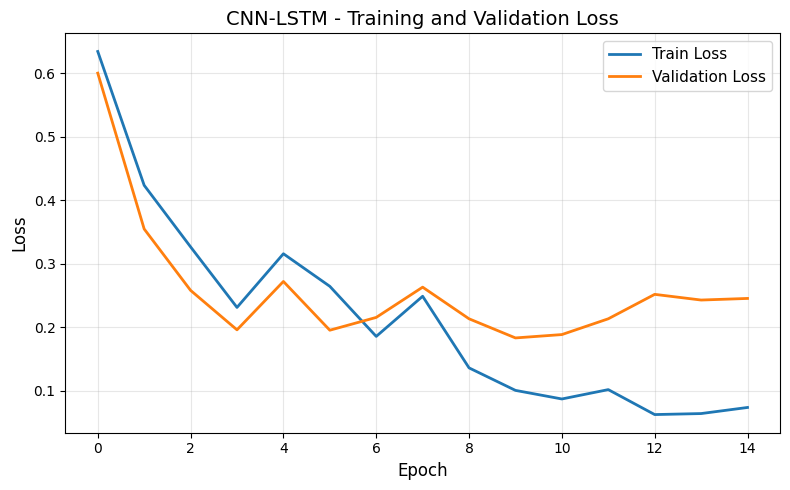

In [ ]:
# Plot loss curves (averaged over 5 runs)
# Run the "Prepare Data and Train" cell (Section 3) first to define all_run_histories
if 'all_run_histories' not in globals() or not all_run_histories:
    if 'history' in globals() and history:
        print("Note: Using single-run history. Run the training cell (Section 3) first for 5-run average.")
        avg_train_loss = np.array(history['train_loss'])
        avg_val_loss = np.array(history['val_loss'])
        std_train_loss = np.zeros_like(avg_train_loss)
        std_val_loss = np.zeros_like(avg_val_loss)
        plot_title = 'CNN-LSTM - Training and Validation Loss (single run)'
    else:
        raise NameError("Run the 'Prepare Data and Train' cell (Section 3) first to create all_run_histories.")
else:
    # Pad shorter runs with last value to handle different early-stopping epochs
    def pad_to_length(lst, length):
        if len(lst) >= length:
            return np.array(lst[:length])
        last = lst[-1] if lst else 0
        return np.array(lst + [last] * (length - len(lst)))
    max_epochs = max(len(h['train_loss']) for h in all_run_histories)
    train_losses = np.array([pad_to_length(h['train_loss'], max_epochs) for h in all_run_histories])
    val_losses = np.array([pad_to_length(h['val_loss'], max_epochs) for h in all_run_histories])
    avg_train_loss = np.mean(train_losses, axis=0)
    avg_val_loss = np.mean(val_losses, axis=0)
    std_train_loss = np.std(train_losses, axis=0)
    std_val_loss = np.std(val_losses, axis=0)
    plot_title = 'CNN-LSTM - Training and Validation Loss (avg over 5 runs)'

plt.figure(figsize=(8, 5))
epochs = np.arange(1, len(avg_train_loss) + 1)
plt.plot(epochs, avg_train_loss, label='Train Loss (avg)', linewidth=2)
plt.fill_between(epochs, avg_train_loss - std_train_loss, avg_train_loss + std_train_loss, alpha=0.2)
plt.plot(epochs, avg_val_loss, label='Validation Loss (avg)', linewidth=2)
plt.fill_between(epochs, avg_val_loss - std_val_loss, avg_val_loss + std_val_loss, alpha=0.2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title(plot_title, fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrices: test set (last run) and full dataset (all samples)
# Auto-install seaborn if missing
try:
    import seaborn as sns
except ImportError:
    print("Warning: seaborn not found. Installing...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "--quiet"])
    import seaborn as sns
    print("seaborn installed successfully.")

# Test set
cm = test_metrics['confusion_matrix']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-dysgraphic', 'Dysgraphic'],
            yticklabels=['Non-dysgraphic', 'Dysgraphic'])
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('CNN-LSTM - Test Set Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()


# --- Full dataset (all rows in meta_df: train + val + test) ---
trained_model.eval()
full_meta = meta_df.copy()
full_dataset = HandwritingDataset(
    full_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES
)
full_loader = DataLoader(full_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

all_probs_full, all_labels_full = [], []
with torch.no_grad():
    for batch in full_loader:
        x = batch["x"].to(Config.DEVICE)
        y = batch["y"].to(Config.DEVICE)
        lengths = batch["length"].to(Config.DEVICE)
        logits, _ = trained_model(x, lengths)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs_full.append(probs.cpu().numpy())
        all_labels_full.append(y.cpu().numpy())

all_probs_full = np.concatenate(all_probs_full)
all_labels_full = np.concatenate(all_labels_full)
full_metrics = compute_metrics(all_labels_full, all_probs_full)
cm_full = full_metrics["confusion_matrix"]
n_all = len(full_meta)

print(f"\nFull dataset ({n_all} samples):")
print(f"  Accuracy: {full_metrics['accuracy']:.4f}")
print(f"  Confusion matrix:\n{cm_full}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-dysgraphic", "Dysgraphic"],
            yticklabels=["Non-dysgraphic", "Dysgraphic"])
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.title(f"CNN-LSTM - Full Dataset Confusion Matrix (N={n_all})", fontsize=14)
plt.tight_layout()
plt.show()
